# Common Test I : Multi-Class Classification
## Classification of Lensing Images

The task was to classify strong lensing images into three categories: no substructure, subhalo substructure, and vortex substructure. The provided images have already been normalized using min-max normalization, however, I still used some data augmentation methods discussed later. I used **EfficientNet-B0** pretrained on ImageNet, fine-tuned in different phases.

**Why I chose this particular model only?**

EfficientNet-B0 uses different parameters for scaling. It balances depth, width, and resolution together rather than scaling one dimension arbitrarily. This makes it ideal for detecting the ring and arc features that distinguish lensing classes. The built-in Squeeze-and-Excitation blocks also help the model learn which channels matter most, which is useful when the differences between `sphere` and `vort` substructure are subtle. It has only 4M parameters so it's lightweight enough to train quickly on general hardware and gives similar accuracy as compared to more complex and deeper models.

The Squeeze-and-Excitation (SE) block is a lightweight architectural unit designed to improve Convolutional Neural Network (CNN) performance by explicitly modeling channel-wise interdependencies. I researched only and first read about it from this article https://medium.com/@tahasamavati/squeeze-and-excitation-explained-387b5981f249. This was one of the main reason I didn't preferred ResNet here.

## Setup

Imports, seeds, and device detection.

In [1]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    n = torch.cuda.device_count()
    for i in range(n):
        print(f'  GPU {i} : {torch.cuda.get_device_name(i)}')
    print(f'  Count  : {n} GPU(s) available')

Device : cuda
  GPU 0 : Tesla T4
  GPU 1 : Tesla T4
  Count  : 2 GPU(s) available


## Configuration

All hyperparameters are kept in a single `CFG` dictionary so they're easy to find and change in one place.

In [ ]:
CFG = dict(
    data_root     = '/kaggle/input/datasets/dmitriizagorulia/gsoc-deeplense-common/dataset',
    save_path     = '/kaggle/working/best_model.pth',
    classes       = ['no', 'sphere', 'vort'],

    batch_size    = 64,
    num_workers   = 4,

    # Phase 1
    phase1_epochs = 5,
    lr_head       = 1e-3,

    # Phase 2
    phase2_epochs = 20,
    lr_backbone   = 1e-4,   # lower LR for pretrained layers
    lr_head2      = 3e-4,   # slightly higher for head

    weight_decay  = 1e-4,
    label_smooth  = 0.1,
    dropout       = 0.3,
)
CLASS2IDX = {c:i for i,c in enumerate(CFG['classes'])}
IDX2CLASS  = {i:c for c,i in CLASS2IDX.items()}
print('Classes :', CLASS2IDX)
print(f'Total epochs : {CFG["phase1_epochs"]} + {CFG["phase2_epochs"]} = {CFG["phase1_epochs"]+CFG["phase2_epochs"]}')

Classes : {'no': 0, 'sphere': 1, 'vort': 2}
Total epochs : 5 + 20 = 25


## Dataset

The dataset has three classes --> `no` (no substructure), `sphere` (subhalo), and `vort` (vortex). Each sample is a `.npy` file with shape `(1, 150, 150)`, normalized to [0, 1]. The single channel is repeated to 3 channels to match ImageNet-pretrained input type.

In [ ]:
class LensDataset(Dataset):
    def __init__(self, root, split, classes, transform=None):
        self.transform = transform
        self.samples   = []
        for cls in classes:
            for fp in sorted(Path(root).joinpath(split, cls).glob('*.npy')):
                self.samples.append((fp, CLASS2IDX[cls]))
        random.shuffle(self.samples)
        counts = np.bincount([s[1] for s in self.samples])
        print(f'[{split:5s}] {len(self.samples)} samples | {dict(zip(classes, counts))}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path).astype(np.float32)  
        arr = arr.clip(0, 1)
        arr = np.repeat(arr, 3, axis=0)         
        img = torch.from_numpy(arr)
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        return np.bincount([s[1] for s in self.samples], minlength=len(CLASS2IDX))

## Data Augmentation & Loaders

Since gravitational lenses have no preferred orientation, random flips and rotations are valid augmentations without introducing any physical bias. A weighted random sampler is used to handle class imbalance during training.

In [ ]:
# Transformations used based on what ImageNet expects from us, since the model was trained on Imagenet afterall
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

TRAIN_TF = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),          # lensing has no preferred orientation
    transforms.Normalize(MEAN, STD),
])
VAL_TF = transforms.Compose([
    transforms.Normalize(MEAN, STD),
])

train_ds = LensDataset(CFG['data_root'], 'train', CFG['classes'], TRAIN_TF)
val_ds   = LensDataset(CFG['data_root'], 'val',   CFG['classes'], VAL_TF)

# This handles class imbalance
counts  = train_ds.class_counts()
w       = 1.0 / (counts.astype(float) + 1e-8)
sampler = WeightedRandomSampler([w[s[1]] for s in train_ds.samples], len(train_ds))

train_loader = DataLoader(train_ds, CFG['batch_size'], sampler=sampler,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
print(f'Batches - train: {len(train_loader)}  val: {len(val_loader)}')

[train] 30000 samples | {'no': np.int64(10000), 'sphere': np.int64(10000), 'vort': np.int64(10000)}
[val  ] 7500 samples | {'no': np.int64(2500), 'sphere': np.int64(2500), 'vort': np.int64(2500)}
Batches — train: 468  val: 118


In [ ]:
# Just Checking
imgs, labels = next(iter(train_loader))
print(f'Batch : {imgs.shape} | dtype: {imgs.dtype} | range: [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Labels: {labels[:10].tolist()}')

Batch : torch.Size([64, 3, 150, 150]) | dtype: torch.float32 | range: [-2.12, 2.64]
Labels: [2, 0, 0, 0, 2, 0, 1, 2, 1, 0]


## The Main Model

EfficientNet-B0 with pretrained ImageNet weights. DataParallel is used automatically if more than one GPU is available for efficient computations.

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=CFG['dropout']),
    nn.Linear(in_feats, len(CFG['classes']))
)
model = model.to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f'Using DataParallel across {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {total/1e6:.2f}M total  |  {trainable/1e6:.2f}M trainable')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 226MB/s]

Using DataParallel across 2 GPUs
Params: 4.01M total  |  4.01M trainable


In [ ]:
def get_base(model):
    """Unwrap DataParallel if needed."""
    return model.module if isinstance(model, nn.DataParallel) else model

def freeze_backbone(model):
    base = get_base(model)
    for name, p in base.named_parameters():
        p.requires_grad = ('classifier' in name)
    frozen = sum(not p.requires_grad for p in base.parameters())
    print(f'Frozen {frozen} params | trainable: {sum(p.requires_grad for p in base.parameters())}')

def unfreeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = True
    print(f'All {sum(p.requires_grad for p in model.parameters())} params unfrozen')

# These functions helps to control which wts to train specifically

## Training & Evaluation

I used Standard cross-entropy with a bit of label smoothing (0.1) so the model doesn't get overconfident on the training set. Gradient clipped at 1.0 which keeps things from blowing up during training. 

For AUC, I'm using macro-average across all the three classes with one-vs-rest ROC curves, which is the standard way to handle multiclass AUC.

In [ ]:
# Training and Evaluation
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])

def compute_auc(probs, labels_np):
    probs = np.asarray(probs)
    labels_np = np.asarray(labels_np)
    
    desc_sort_order = np.argsort(-probs)
    probs = probs[desc_sort_order]
    labels_np = labels_np[desc_sort_order]
    
    P = np.sum(labels_np == 1)
    N = np.sum(labels_np == 0)
    
    # undefined case
    if P == 0 or N == 0:
        return 0.0  
    
    tp = 0
    fp = 0
    
    tpr = []
    fpr = []
    
    for label in labels_np:
        if label == 1:
            tp += 1
        else:
            fp += 1
        
        tpr.append(tp / P)
        fpr.append(fp / N)
    
    tpr = np.array(tpr)
    fpr = np.array(fpr)
    
    tpr = np.concatenate(([0], tpr))
    fpr = np.concatenate(([0], fpr))
    
    # Computing AUC using trapezoidal rule
    auc = np.trapz(tpr, fpr)
    return auc
    
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = correct = total = 0
    probs_all, labels_all = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out   = model(imgs)
        probs = torch.softmax(out, 1)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
        probs_all.append(probs.cpu().numpy())
        labels_all.append(labels.cpu().numpy())
    return (total_loss / total, correct / total, np.concatenate(probs_all), np.concatenate(labels_all))

def macro_auc(probs, labels):
    yb = label_binarize(labels, classes=list(range(len(CFG['classes']))))
    return np.mean([auc(*roc_curve(yb[:, i], probs[:, i])[:2])
                    for i in range(len(CFG['classes']))])

def run_loop(epochs, optimizer, scheduler, phase_name, history, best_auc):
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta              = train_epoch(model, train_loader, optimizer)
        vl, va, probs, lbls = evaluate(model, val_loader)
        vauc                = macro_auc(probs, lbls)
        scheduler.step()    # once per epoch ✅
        elapsed = time.time() - t0

        for k, v in zip(['tl','vl','ta','va','auc'], [tl,vl,ta,va,vauc]):
            history[k].append(v)

        tag = ''
        if vauc > best_auc:
            best_auc = vauc
            torch.save(get_base(model).state_dict(), CFG['save_path'])
            tag = '  ✅ best'

        print(f'[{phase_name}] Ep {ep:02d}/{epochs} '
              f'| Loss {tl:.4f}/{vl:.4f} '
              f'| Acc {ta:.3f}/{va:.3f} '
              f'| AUC {vauc:.4f} '
              f'| {elapsed:.0f}s{tag}')
    return best_auc

**Why I am using a 2-phase training Pipeline?**

Directly fine-tuning all layers from the start can disrupt pretrained features early in training when the new classifier head is still random. Phase 1 freezes the backbone and only trains the head for a few epochs to stabilize it first. 

Phase 2 then unfreezes everything and fine-tunes with a lower learning rate on the backbone to gently adapt the ImageNet features toward the lensing domain.

## Phase 1

The backbone is frozen. Only the new classifier head is trained for 5 epochs with a higher learning rate. This prevents the pretrained features from being corrupted before the head has learned anything meaningful.

In [ ]:
history  = dict(tl=[], vl=[], ta=[], va=[], auc=[])
best_auc = 0.0

freeze_backbone(model)

opt1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=CFG['lr_head'], weight_decay=CFG['weight_decay'])
sch1 = optim.lr_scheduler.CosineAnnealingLR(
    opt1, T_max=CFG['phase1_epochs'], eta_min=1e-5)

print('=' * 65)
print('PHASE 1 — Head only (backbone frozen)')
print('=' * 65)
best_auc = run_loop(CFG['phase1_epochs'], opt1, sch1, 'P1', history, best_auc)

Frozen 211 params | trainable: 2
PHASE 1 — Head only (backbone frozen)
[P1] Ep 01/5 | Loss 1.1135/1.1316 | Acc 0.355/0.354 | AUC 0.5421 | 91s  ✅ best
[P1] Ep 02/5 | Loss 1.1112/1.0942 | Acc 0.360/0.383 | AUC 0.5663 | 96s  ✅ best
[P1] Ep 03/5 | Loss 1.1047/1.0941 | Acc 0.367/0.381 | AUC 0.5636 | 79s
[P1] Ep 04/5 | Loss 1.1003/1.0880 | Acc 0.369/0.390 | AUC 0.5708 | 78s  ✅ best
[P1] Ep 05/5 | Loss 1.0974/1.0875 | Acc 0.374/0.393 | AUC 0.5716 | 77s  ✅ best


## Phase 2 

All layers are unfrozen. Differential learning rates are used. I used 3x lower learning rate for the backbone than the head to preserve the pretrained features while still allowing domain adaptation to lensing data

**Note:** The Kaggle session crashed midway through this phase due to the hardware limits. The best checkpoint was saved automatically during training, and training was resumed from that point in the next cell as training the whole thing again was getting expensive in time and computational power.

In [ ]:
unfreeze_backbone(model)

base = get_base(model)
opt2 = optim.AdamW([
    {'params': base.features.parameters(),   'lr': CFG['lr_backbone']},
    {'params': base.classifier.parameters(), 'lr': CFG['lr_head2']},
], weight_decay=CFG['weight_decay'])

sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=CFG['phase2_epochs'], eta_min=1e-7)

print('=' * 65)
print('PHASE 2 — Full fine-tune (differential LR)')
print(f'  backbone lr: {CFG["lr_backbone"]}  |  head lr: {CFG["lr_head2"]}')
print('=' * 65)
best_auc = run_loop(CFG['phase2_epochs'], opt2, sch2, 'P2', history, best_auc)

print(f'\n Best Macro-AUC: {best_auc:.4f}')

All 213 params unfrozen
PHASE 2 — Full fine-tune (differential LR)
  backbone lr: 0.0001  |  head lr: 0.0003
[P2] Ep 01/20 | Loss 1.0725/1.0488 | Acc 0.416/0.452 | AUC 0.6533 | 98s  ✅ best
[P2] Ep 02/20 | Loss 0.9887/0.9306 | Acc 0.519/0.571 | AUC 0.7692 | 99s  ✅ best
[P2] Ep 03/20 | Loss 0.8971/0.8250 | Acc 0.604/0.661 | AUC 0.8387 | 100s  ✅ best
[P2] Ep 04/20 | Loss 0.8329/0.8082 | Acc 0.655/0.685 | AUC 0.8635 | 100s  ✅ best
[P2] Ep 05/20 | Loss 0.7862/0.7071 | Acc 0.692/0.751 | AUC 0.8979 | 100s  ✅ best
[P2] Ep 06/20 | Loss 0.7438/0.6640 | Acc 0.723/0.777 | AUC 0.9179 | 99s  ✅ best
[P2] Ep 07/20 | Loss 0.7069/0.6508 | Acc 0.749/0.787 | AUC 0.9285 | 100s  ✅ best
[P2] Ep 08/20 | Loss 0.6756/0.6419 | Acc 0.768/0.794 | AUC 0.9331 | 100s  ✅ best
[P2] Ep 09/20 | Loss 0.6657/0.6713 | Acc 0.777/0.791 | AUC 0.9284 | 100s
[P2] Ep 10/20 | Loss 0.6442/0.5767 | Acc 0.790/0.833 | AUC 0.9508 | 98s  ✅ best
[P2] Ep 11/20 | Loss 0.6244/0.5836 | Acc 0.804/0.830 | AUC 0.9526 | 99s  ✅ best
[P2] Ep 12/20

## Resuming Training from Checkpoint

The session timed out during Phase 2. Since the best weights were saved after every improvement, training was resumed directly from that checkpoint.

In [ ]:
RESUME_PATH    = '/kaggle/input/datasets/sourishkumardutta/auc0-9674-efficient-netb0/best_model (6).pth'
EXTRA_EPOCHS   = 15    
PREV_BEST_AUC  = 0.9808 

# Rebuilding and loading the model
model = models.efficientnet_b0(weights=None)
in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(p=CFG['dropout']), nn.Linear(in_feats, len(CFG['classes'])))

state = torch.load(RESUME_PATH, map_location=DEVICE)
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model = model.to(DEVICE)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

print(f'✅ Loaded weights from: {RESUME_PATH}')

unfreeze_backbone(model)
base = get_base(model)

opt2 = optim.AdamW([
    {'params': base.features.parameters(),   'lr': CFG['lr_backbone']},
    {'params': base.classifier.parameters(), 'lr': CFG['lr_head2']},
], weight_decay=CFG['weight_decay'])

sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EXTRA_EPOCHS, eta_min=1e-7)

history  = dict(tl=[], vl=[], ta=[], va=[], auc=[])

print('=' * 65)
print(f'PHASE 2 RESUME — {EXTRA_EPOCHS} epochs | full fine-tune')
print(f'  backbone lr: {CFG["lr_backbone"]}  |  head lr: {CFG["lr_head2"]}')
print(f'  picking up from AUC: {PREV_BEST_AUC}')
print('=' * 65)

best_auc = run_loop(EXTRA_EPOCHS, opt2, sch2, 'P2', history, PREV_BEST_AUC)
print(f'\n🏆 Best Macro-AUC: {best_auc:.4f}')

✅ Loaded weights from: /kaggle/input/datasets/sourishkumardutta/auc0-9674-efficient-netb0/best_model (6).pth
All 213 params unfrozen
PHASE 2 RESUME — 15 epochs | full fine-tune
  backbone lr: 0.0001  |  head lr: 0.0003
  picking up from AUC: 0.9808
[P2] Ep 01/15 | Loss 0.5017/0.5169 | Acc 0.881/0.878 | AUC 0.9699 | 98s
[P2] Ep 02/15 | Loss 0.5003/0.4756 | Acc 0.881/0.897 | AUC 0.9772 | 92s
[P2] Ep 03/15 | Loss 0.4962/0.4841 | Acc 0.885/0.894 | AUC 0.9799 | 93s
[P2] Ep 04/15 | Loss 0.4840/0.4553 | Acc 0.892/0.911 | AUC 0.9823 | 92s  ✅ best
[P2] Ep 05/15 | Loss 0.4840/0.4940 | Acc 0.892/0.888 | AUC 0.9767 | 93s
[P2] Ep 06/15 | Loss 0.4728/0.4863 | Acc 0.899/0.894 | AUC 0.9790 | 93s
[P2] Ep 07/15 | Loss 0.4615/0.4331 | Acc 0.906/0.922 | AUC 0.9857 | 93s  ✅ best
[P2] Ep 08/15 | Loss 0.4553/0.4604 | Acc 0.910/0.910 | AUC 0.9817 | 94s
[P2] Ep 09/15 | Loss 0.4522/0.4202 | Acc 0.911/0.930 | AUC 0.9875 | 94s  ✅ best
[P2] Ep 10/15 | Loss 0.4469/0.4546 | Acc 0.915/0.912 | AUC 0.9806 | 95s
[P2] Ep

## Final Evaluation

The best checkpoint (highest macro-AUC on validation) is loaded and evaluated on the full validation set.

In [ ]:
best_model = models.efficientnet_b0()
best_model.classifier = nn.Sequential(
    nn.Dropout(p=CFG['dropout']),
    nn.Linear(best_model.classifier[1].in_features, len(CFG['classes']))
)
best_model.load_state_dict(torch.load(CFG['save_path'], map_location=DEVICE))
best_model = best_model.to(DEVICE)

_, val_acc, val_probs, val_labels = evaluate(best_model, val_loader)
val_preds = val_probs.argmax(1)
print(f'Val Accuracy : {val_acc:.4f}')
print(classification_report(val_labels, val_preds, target_names=CFG['classes']))

Val Accuracy : 0.9344
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      2500
      sphere       0.95      0.86      0.91      2500
        vort       0.94      0.95      0.95      2500

    accuracy                           0.93      7500
   macro avg       0.94      0.93      0.93      7500
weighted avg       0.94      0.93      0.93      7500



## Results

Training curves, ROC curves per class, and the confusion matrix on the validation set.

In [ ]:
n_cls = len(CFG['classes'])
y_bin = label_binarize(val_labels, classes=list(range(n_cls)))
fpr_d, tpr_d, auc_d = {}, {}, {}
for i, cls in enumerate(CFG['classes']):
    fpr_d[cls], tpr_d[cls], _ = roc_curve(y_bin[:, i], val_probs[:, i])
    auc_d[cls] = auc(fpr_d[cls], tpr_d[cls])

all_fpr   = np.unique(np.concatenate(list(fpr_d.values())))
mean_tpr  = np.mean([np.interp(all_fpr, fpr_d[c], tpr_d[c]) for c in CFG['classes']], axis=0)
macro_AUC = auc(all_fpr, mean_tpr)

print('Per-class AUC:')
for cls in CFG['classes']:
    print(f'  {cls:8s}: {auc_d[cls]:.4f}')
print(f'  {"MACRO":8s}: {macro_AUC:.4f}')

Per-class AUC:
  no      : 0.9927
  sphere  : 0.9817
  vort    : 0.9934
  MACRO   : 0.9894


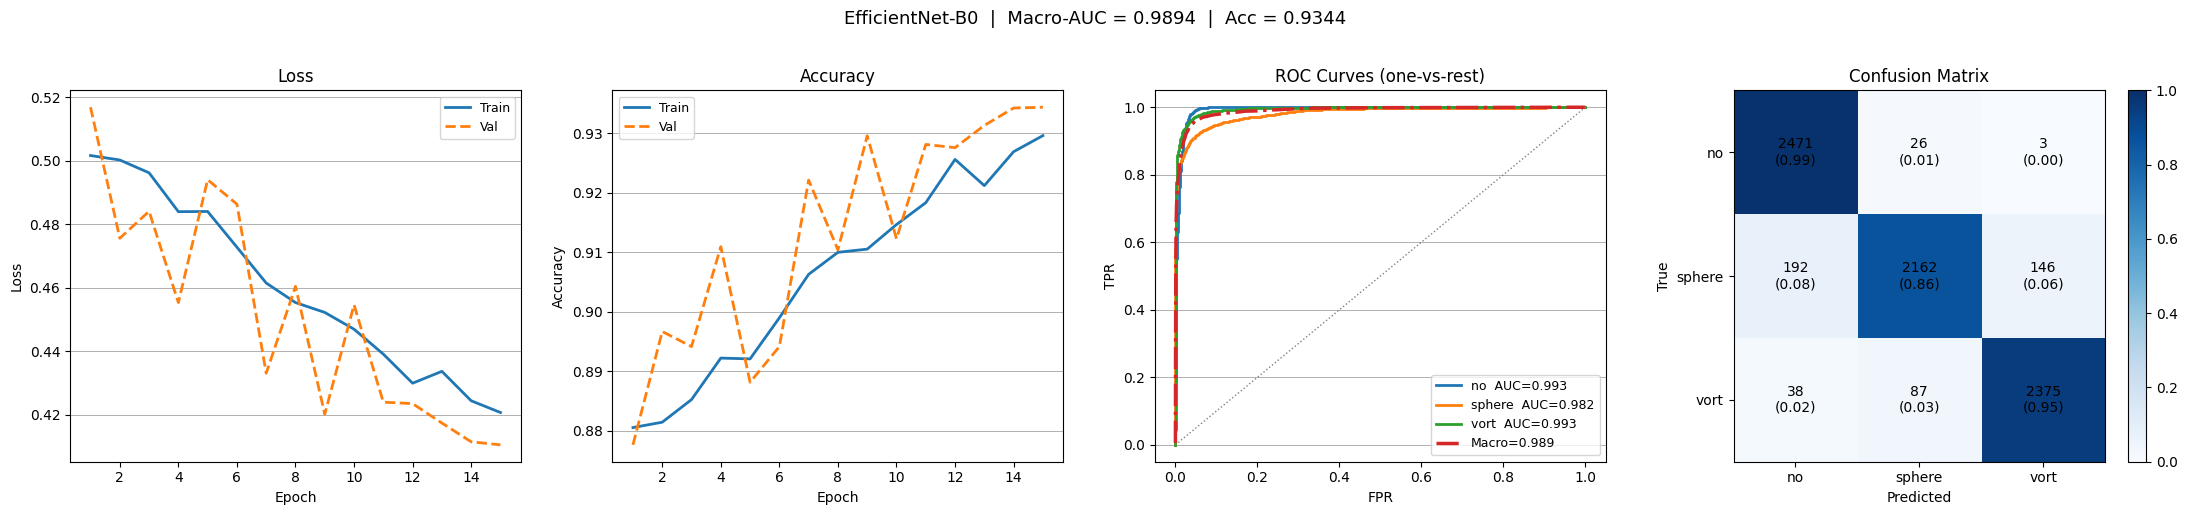

Saved


In [ ]:
# Plots
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

epochs_x = list(range(1, len(history['tl']) + 1))

# 1 · Loss
axes[0].plot(epochs_x, history['tl'], lw=2, label='Train')
axes[0].plot(epochs_x, history['vl'], lw=2, ls='--', label='Val')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontsize=12)
axes[0].yaxis.grid(True, lw=0.7); axes[0].set_axisbelow(True)

# 2 · Accuracy
axes[1].plot(epochs_x, history['ta'], lw=2, label='Train')
axes[1].plot(epochs_x, history['va'], lw=2, ls='--', label='Val')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontsize=12)
axes[1].yaxis.grid(True, lw=0.7); axes[1].set_axisbelow(True)

# 3 · ROC
for i, cls in enumerate(CFG['classes']):
    axes[2].plot(fpr_d[cls], tpr_d[cls], lw=2, label=f'{cls}  AUC={auc_d[cls]:.3f}')
axes[2].plot(all_fpr, mean_tpr, lw=2.5, ls='-.', label=f'Macro={macro_AUC:.3f}')
axes[2].plot([0,1],[0,1], color='gray', lw=1, ls=':')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].legend(fontsize=9)
axes[2].set_title('ROC Curves (one-vs-rest)', fontsize=12)
axes[2].yaxis.grid(True, lw=0.7); axes[2].set_axisbelow(True)

# 4 · Confusion Matrix
cm  = confusion_matrix(val_labels, val_preds)
cmn = cm / cm.sum(axis=1, keepdims=True)
im  = axes[3].imshow(cmn, cmap='Blues', vmin=0, vmax=1)
for r in range(n_cls):
    for c in range(n_cls):
        axes[3].text(c, r, f'{cm[r,c]}\n({cmn[r,c]:.2f})',
                     ha='center', va='center', fontsize=10)
axes[3].set_xticks(range(n_cls)); axes[3].set_xticklabels(CFG['classes'])
axes[3].set_yticks(range(n_cls)); axes[3].set_yticklabels(CFG['classes'])
axes[3].set_xlabel('Predicted'); axes[3].set_ylabel('True')
axes[3].set_title('Confusion Matrix', fontsize=12)
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.suptitle(
    f'EfficientNet-B0  |  Macro-AUC = {macro_AUC:.4f}  |  Acc = {val_acc:.4f}',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

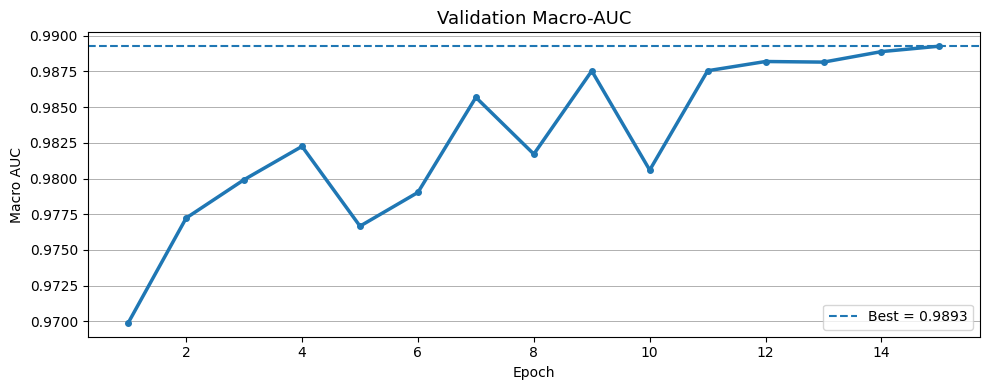

In [ ]:
# AUC vs. Epoch Tracked Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs_x, history['auc'], lw=2.5, marker='o', ms=4)
ax.axhline(best_auc, ls='--', lw=1.5, label=f'Best = {best_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.set_title('Validation Macro-AUC', fontsize=13)
ax.legend()
ax.yaxis.grid(True, lw=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/kaggle/working/auc_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Predictions

Probabilities for each sample, true labels, and predicted labels are saved to a CSV for easy access, further reference and submission

In [ ]:
# saving using pandas
df = pd.DataFrame(val_probs, columns=[f'prob_{c}' for c in CFG['classes']])
df['true'] = [IDX2CLASS[l] for l in val_labels]
df['pred'] = [IDX2CLASS[p] for p in val_preds]
df['correct'] = df['true'] == df['pred']
df.to_csv('/kaggle/working/val_predictions.csv', index=False)
print(df.head())
print(f'\nMacro-AUC = {macro_AUC:.4f}  |  Acc = {val_acc:.4f}')
print('All files of this model are saved successfully!')

    prob_no  prob_sphere  prob_vort  true  pred  correct
0  0.942325     0.031481   0.026195    no    no     True
1  0.899502     0.067429   0.033069    no    no     True
2  0.029918     0.034861   0.935221  vort  vort     True
3  0.038920     0.028881   0.932198  vort  vort     True
4  0.022937     0.078219   0.898843  vort  vort     True

Macro-AUC = 0.9894  |  Acc = 0.9344
All files of this model are saved successfully!


P.S. *AI coding assistant was used during development for boilerplate and syntax. All architectural decisions, training strategy, and design choices are my own.*